# Horse racing data analysis

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from package import algorithm


file_name = 'runs.csv'
processed_data = 'runs(preprocessing).csv'
current_path = os.getcwd()
data_path = current_path + '\\' + 'data' + '\\' + 'horse racing data' + '\\' 
image_path = current_path + '\\' + 'image' + '\\' + 'horse racing' + '\\' 

name_columns = 'Horse'
covariate_columns = ['Act. Wt.','Dr.','Win Odds']

### Data preprocessing

Drop Nan

In [2]:
df = pd.read_csv(data_path + file_name,index_col='race_id')
NaN_columns = covariate_columns+['Pla.']
for covariate in NaN_columns:
    df[covariate] = pd.to_numeric(df[covariate], errors='coerce')
    df = df.dropna(subset=[covariate])


Select suitable matches and players

In [3]:
def delete_matches(df,m_lower=0,m_upper=100):
    df = df.copy()
    i = 0
    indexes = []
    for index in df.index.unique():
        m = df[df.index == index].shape[0]
        if m >= m_lower and m <= m_upper:
            i += 1
        else:
            indexes.append(index)
    df = df.drop(index = indexes)
    return df,i

def delete_players(df,d_min=0,name = 'Horse'):
    counts = df[name].value_counts()
    values_to_keep = counts[counts >= d_min].index
    df = df[df[name].isin(values_to_keep)]
    return df,len(values_to_keep)

def select(df,m_lower=0,m_upper=100,d_min=0,name = 'Horse'):
    NN = len(df.index.unique())
    nn = len(df[name].value_counts())
    while True:
        print('-'*10)
        print(f'The number of matches: {NN}')
        print(f'The number of horses: {nn}')
        df,N = delete_matches(df,m_lower,m_upper)
        df,n = delete_players(df,d_min)
        if NN == N and nn == n:
            break
        else:
            NN = N
            nn = n
    return df,n,N

In [4]:
m_lower = 4
m_upper = 14
d_min = 10
df,n,N = select(df,m_lower,m_upper,d_min)

----------
The number of matches: 6348
The number of horses: 4405
----------
The number of matches: 6348
The number of horses: 2817
----------
The number of matches: 6328
The number of horses: 2814


Normalization

In [5]:
# Actual Weight
df['Act. Wt.'] = np.log(df['Act. Wt.'])
mean_A = df['Act. Wt.'].mean()
std_A = df['Act. Wt.'].std()
df['Act. Wt.'] = (df['Act. Wt.'] - mean_A) / std_A
# Draw
df['Dr.'] = df['Dr.'].astype(float)
for index in df.index.unique():
    df.loc[index,'Dr.'] = pd.Series(df.loc[index,'Dr.']/max(df.loc[index,'Dr.']))
# Belief
for index in df.index.unique():
    t = 1/df.loc[index,'Win Odds']
    df.loc[index,'Win Odds'] = np.log(t / np.sum(t))

In [6]:
df.to_csv(data_path+processed_data)

### Data Analysis

Construct T and X

In [7]:
df = pd.read_csv(data_path + processed_data,index_col='race_id',low_memory=False)


horseID = {}
T = []
cov = []
for index in df.index.unique():
    temp = df.loc[index].sort_values(by='Pla.')
    
    ### covariates
    x = np.array(temp[covariate_columns])
    cov.append(x)

    t = []
    horses_name = temp[name_columns].tolist()
    for i,horse_name in enumerate(horses_name):
        added_horse = horseID.keys()
        if horse_name in added_horse:
            horseID[horse_name]['times'] += 1
        else:
            n = len(added_horse)
            horseID[horse_name] = {'ID':n,'times':1,'place':[],'covariate':[]}
        horseID[horse_name]['place'].append(i+1)
        horseID[horse_name]['covariate'].append(x[i])
        t.append(horseID[horse_name]['ID'])
    T.append(t)
n = len(horseID)

In [29]:
df = pd.read_csv(data_path + processed_data,index_col='race_id',low_memory=False)


horseID = {}
T = []
cov = []
for index in df.index.unique():
    temp = df.loc[index].sort_values(by='Pla.')    

    ### covariates
    x = np.array(temp[covariate_columns])
    cov.append(x)
    place = np.array(temp['Pla.'])
    
    ###
    t = []
    horses_name = temp[name_columns].tolist()
    for i,horse_name in enumerate(horses_name):
        added_horse = horseID.keys()
        if horse_name in added_horse:
            horseID[horse_name]['times'] += 1
        else:
            n = len(added_horse)
            horseID[horse_name] = {'ID':n,'times':1,'place':[],'covariate':[]}
        #horseID[horse_name]['place'].append(i+1)
        horseID[horse_name]['place'].append(place[i])
        xx = x[i].copy()
        xx[-1] = np.exp(xx[-1])
        horseID[horse_name]['covariate'].append(xx)
        t.append(horseID[horse_name]['ID'])
    T.append(t)
n = len(horseID)
N = len(T)

#### Analysis

PlusDC

In [9]:
u_plusDC,v_plusDC = algorithm.AM(T,cov,n,
                                 E=1e-5,Eu=1e-5,Ev=1e-12,
                                 I=52,detail=True)
l_plusDC = algorithm.multi_likelihood(T,cov,u_plusDC,v_plusDC)

-----1-----
log-likelihood: -18.859192620619336
v iterative times: 6 and v = [-0.02473556 -0.09376191  0.5810856 ]
u iterative times: 52
-----2-----
log-likelihood: -17.037245968275066
v iterative times: 5 and v = [-0.096561   -0.15920727  0.53608646]
u iterative times: 52
-----3-----
log-likelihood: -16.99292532905669
v iterative times: 5 and v = [-0.12270102 -0.17647121  0.51603965]
u iterative times: 52
-----4-----
log-likelihood: -16.986257972657747
v iterative times: 4 and v = [-0.13252882 -0.18302773  0.50772327]
u iterative times: 52
-----5-----
log-likelihood: -16.98523852042528
v iterative times: 4 and v = [-0.13629298 -0.18565049  0.50436725]
u iterative times: 42
-----6-----
log-likelihood: -16.98508212086962
v iterative times: 4 and v = [-0.13774407 -0.18669121  0.50303681]
u iterative times: 32
-----7-----
log-likelihood: -16.985058156877734
v iterative times: 4 and v = [-0.13830596 -0.18710116  0.50251318]
u iterative times: 22


In [10]:
likelihood = algorithm.multi_likelihood(T,cov,u_plusDC,v_plusDC)
v_plusDC

array([-0.13852392, -0.18726204,  0.5023077 ])

In [11]:
import itertools
from joblib import Parallel, delayed
# models
def get_results(T,cov,s,N,n):
    X = [x[:,s] for x in cov]
    d = len(s)
    u_plusDC,v_plusDC = algorithm.AM(T,X,n,
                                 E=1e-5,Eu=1e-5,Ev=1e-12,
                                 I=52)
    likelihood = algorithm.multi_likelihood(T,X,u_plusDC,v_plusDC)
    AIC = (n-1+d) * 2 / N - 2 * likelihood
    BIC = (n-1+d) * np.log(N) / N - 2 * likelihood
    print(f'{s}:{likelihood},{AIC},{BIC}')
    return [s,likelihood,AIC,BIC]
    

# get_subset
get_subset = lambda n: [subset for i in range(n + 1)
                         for subset in itertools.combinations(list(range(n)), i)]
subset = get_subset(3)
results = Parallel(n_jobs=8)(delayed(get_results)(T,cov,ss,N,n) for ss in subset)

In [12]:
for result in results:
    t = [0,0,0]
    for s in result[0]:
        t[s] = 1
    string = f'subset:{t}, log-likelihood:{result[1]}, AIC:{result[2]},BIC:{result[3]}'
    print(string)

subset:[0, 0, 0], log-likelihood:-17.67061983418555, AIC:36.23030414371876,BIC:39.23211454828194
subset:[1, 0, 0], log-likelihood:-17.649590260365393, AIC:36.18856105170424,BIC:39.19143857692315
subset:[0, 1, 0], log-likelihood:-17.59408695004947, AIC:36.07755443107239,BIC:39.08043195629129
subset:[0, 0, 1], log-likelihood:-17.045592341257624, AIC:34.9805652134887,BIC:37.98344273870761
subset:[1, 1, 0], log-likelihood:-17.573323482590652, AIC:36.03634355178055,BIC:39.04028819765518
subset:[1, 0, 1], log-likelihood:-16.995940701905436, AIC:34.881577990410115,BIC:37.88552263628475
subset:[0, 1, 1], log-likelihood:-17.03343877910368, AIC:34.9565741448066,BIC:37.960518790681235
subset:[1, 1, 1], log-likelihood:-16.98505405733588, AIC:34.86012075689679,BIC:37.86513252342716


PL

In [13]:
u_pl,v_pl = algorithm.AM(T,cov,n,P=True,Eu=1e-5,detail=True)
l_pl = algorithm.multi_likelihood(T,cov,u_pl,v_pl)

In [14]:
sorted_indices = np.argsort(-u_pl)  
ranks_pl = np.empty_like(sorted_indices)
ranks_pl[sorted_indices] = np.arange(1, len(u_pl) + 1) 

In [15]:
plusDC_top10 = np.argsort(u_plusDC)[-10:][::-1]
u_t10_plusDC = u_plusDC[plusDC_top10]
i = 0
for index, uu in zip(plusDC_top10,u_t10_plusDC):
    i += 1
    horse_name = [key for key, value in horseID.items() if value['ID'] == index][0]
    id = horseID[horse_name]['ID']
    times = horseID[horse_name]['times']
    mean_place = np.mean(horseID[horse_name]['place'])
    mean_covariate = np.mean(horseID[horse_name]['covariate'],axis=0)
    uu_pl = u_pl[id]
    print('-'*10+f'Ranking:{i}'+'-'*10)
    print(f'Horse:{horse_name}, ID:{id}')
    print(f'Score_PlusDC:{uu},score_PL:{uu_pl}')
    print(f'Race:{times}, Ranking_PL:{ranks_pl[id]}, Mean_Place:{mean_place}')
    print(f'Mean_covariate:{mean_covariate}\n')

----------Ranking:1----------
Horse:564, ID:999
Score_PlusDC:3.3001277756875256,score_PL:4.344367506488301
Race:11, Ranking_PL:4, Mean_Place:1.3636363636363635
Mean_covariate:[0.63648981 0.50649351 0.40458569]

----------Ranking:2----------
Horse:1033, ID:2029
Score_PlusDC:3.037339318090841,score_PL:4.808684852982008
Race:21, Ranking_PL:1, Mean_Place:1.9523809523809523
Mean_covariate:[0.52825318 0.67821002 0.45061126]

----------Ranking:3----------
Horse:2402, ID:2597
Score_PlusDC:2.94993621160574,score_PL:4.589571817514721
Race:14, Ranking_PL:2, Mean_Place:2.0
Mean_covariate:[0.44559995 0.54868068 0.30865071]

----------Ranking:4----------
Horse:1588, ID:2617
Score_PlusDC:2.730661625761214,score_PL:4.499923679534747
Race:12, Ranking_PL:3, Mean_Place:3.0833333333333335
Mean_covariate:[0.18942195 0.47140822 0.34202692]

----------Ranking:5----------
Horse:160, ID:2800
Score_PlusDC:2.580101770261689,score_PL:3.7775723922600735
Race:11, Ranking_PL:8, Mean_Place:3.1818181818181817
Mean_cov

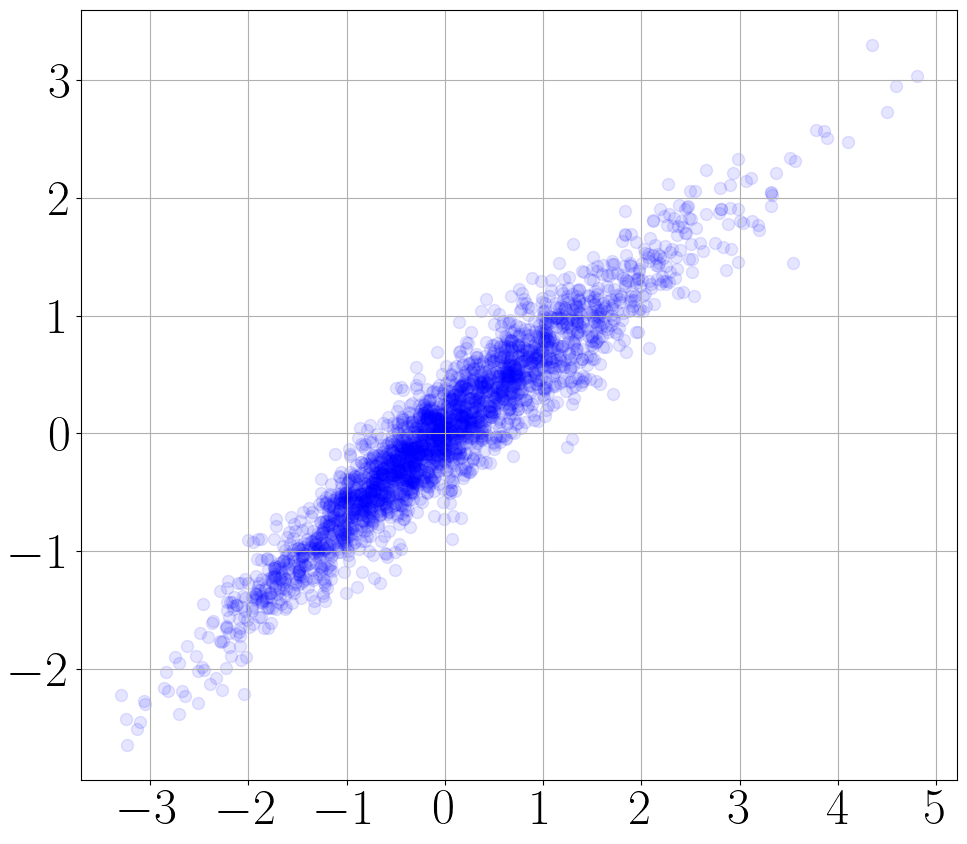

In [16]:
fig,ax = plt.subplots(figsize=(11.3,10))
ax.scatter(u_pl,u_plusDC,s = 75,alpha=0.1,c='blue')
sz = 36
plt.xticks(size = sz)
plt.yticks(size = sz)

rc('text', usetex=True)
rc('font', family='serif')
plt.grid()

plt.savefig(image_path+'score.pdf')
plt.show()

#### $k$-folder Cross Validation

In [30]:
CV_filename = 'cross_validation.txt'

Cross Validation

In [31]:
def cross_validation(T,cov,n,subset):
    N = len(T)
    Ttrain = [T[i] for i in range(N) if i not in subset]
    Xtrain = [cov[i] for i in range(N) if i not in subset]
    Ttest = [T[i] for i in range(N) if i in subset]
    Xtest = [cov[i] for i in range(N) if i in subset]


    u_pl,v_pl = algorithm.AM(Ttrain,Xtrain,n,P=True,Eu=1e-5,detail=True)
    u_plusDC,v_plusDC = algorithm.AM(Ttrain,Xtrain,n,
                                 E=1e-5,Eu=1e-5,Ev=1e-12,
                                 I=52)
    
    full_likelihood_pl = algorithm.multi_likelihood(Ttest,Xtest,u_pl,v_pl)
    top_likelihood_pl = algorithm.multi_likelihood_one(Ttest,Xtest,u_pl,v_pl)
    three_likelihood_pl = algorithm.multi_likelihood_three(Ttest,Xtest,u_pl,v_pl)
    likelihood_pl = [full_likelihood_pl,top_likelihood_pl,three_likelihood_pl]

    full_likelihood_plusDC = algorithm.multi_likelihood(Ttest,Xtest,u_plusDC,v_plusDC)
    top_likelihood_plusDC = algorithm.multi_likelihood_one(Ttest,Xtest,u_plusDC,v_plusDC)
    three_likelihood_plusDC = algorithm.multi_likelihood_three(Ttest,Xtest,u_plusDC,v_plusDC)
    likelihood_plusDC = [full_likelihood_plusDC,top_likelihood_plusDC,three_likelihood_plusDC]

    ### belief
    NN = len(Xtest)
    full_belief,top_belief,three_belief = 0, 0, 0
    for xx in Xtest:
        b = np.exp(xx[:, -1])
        full_belief += sum([np.log(b[j] / sum(b[j:])) for j in range(len(b))])
        top_belief += np.log(b[0] / sum(b))
        three_belief += sum([np.log(b[j] / sum(b[j:])) for j in range(3)])
    full_belief /= NN
    top_belief /= NN
    three_belief /= NN
    belief = [full_belief,top_belief,three_belief]

    results = {'plusDC':likelihood_plusDC,
               'pl':likelihood_pl,
               'belief':belief}

    with open(data_path+CV_filename,'a') as f:
        for values in results.values():
            for value in values:
                f.write(str(value)+',')
            f.write(';')
        f.write('\n')

63-folder

In [45]:
#folders = [[100*i,100*(i+1)] for i in range(62)]+[[6200,N]]
folders = []
np.random.seed(42)
temp_folder = set(range(N))
I = int(N/100)
for i in range(I):
    temp_folder = list(temp_folder)
    index = np.random.choice(temp_folder, 100,replace=False)
    index = np.sort(index)[::-1]
    temp_folder = set(temp_folder) - set(index)
    folders.append(index.tolist())
folders[-1] = folders[-1] +list(temp_folder)

In [33]:
results = Parallel(n_jobs=8)(delayed(cross_validation)(T,cov,n,folder) for folder in folders)

In [34]:
Data = []
with open(data_path+CV_filename,'r') as file:
    for line in file:
        tem = np.zeros((3,3))
        models = line.split(';')[:-1]
        for i in range(3):
            tem[i,:] = list(map(float,models[i].split(',')[:-1]))
        Data.append(tem)
Data = np.array(Data)

C:\Users\13299\AppData\Local\Temp\ipykernel_15036\428577658.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bx = ax.boxplot(Data[:,:,j], labels=label, patch_artist=True,medianprops={'linewidth': 2})


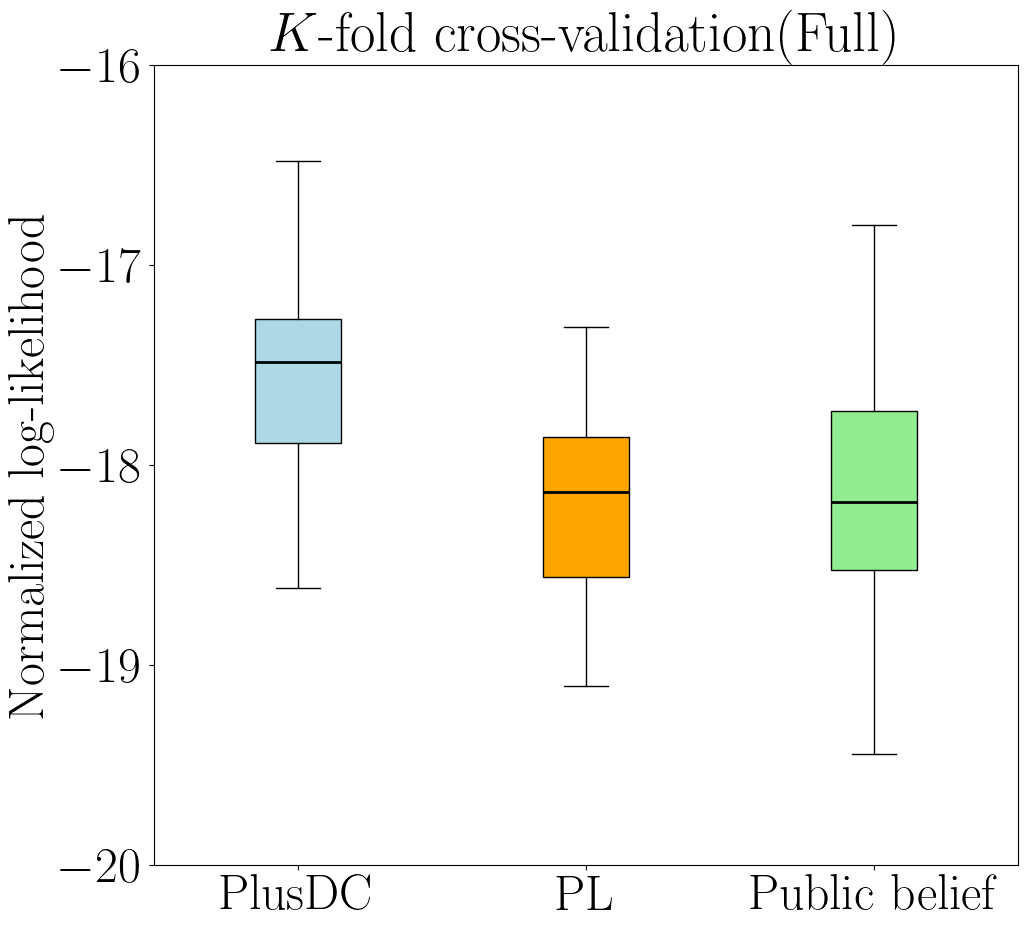

C:\Users\13299\AppData\Local\Temp\ipykernel_15036\428577658.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bx = ax.boxplot(Data[:,:,j], labels=label, patch_artist=True,medianprops={'linewidth': 2})


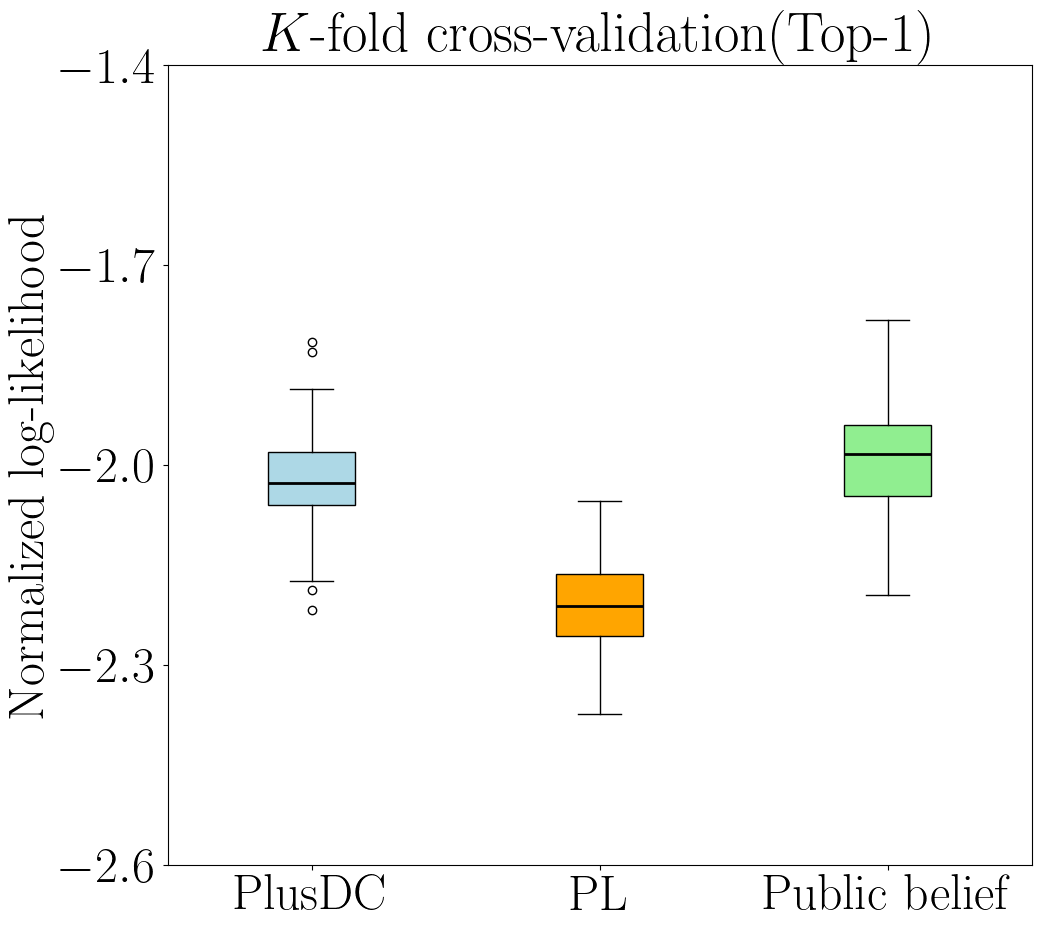

C:\Users\13299\AppData\Local\Temp\ipykernel_15036\428577658.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bx = ax.boxplot(Data[:,:,j], labels=label, patch_artist=True,medianprops={'linewidth': 2})


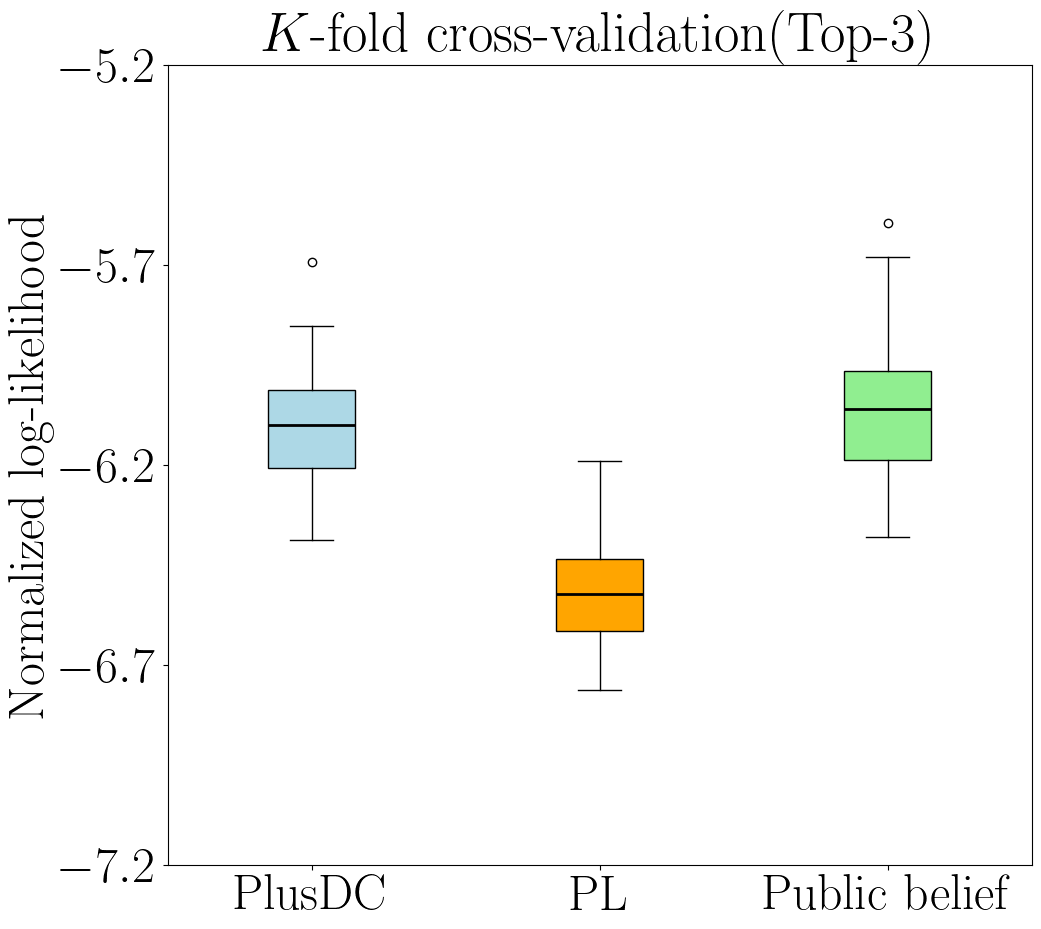

In [38]:
rc('text', usetex=True)
rc('font', family='serif')
save_name = ['full','1','3']
title = ['(Full)', '(Top-1)', '(Top-3)']
label = ['PlusDC', 'PL', 'Public belief']
colors = ['lightblue', 'orange', 'lightgreen']
yrange = [[-20,-19,-18,-17,-16],[-1.4,-1.7,-2.0,-2.3,-2.6],[-5.2,-5.7,-6.2,-6.7,-7.2]]
y_range = [[-20,-16],[-2.5,-1.6],[-7.1, -5.3]]
sz = 36
j = 1


for j in range(3):
    fig, ax = plt.subplots(figsize=(10.8, 10))
    bx = ax.boxplot(Data[:,:,j], labels=label, patch_artist=True,medianprops={'linewidth': 2})
    ax.set_ylim(y_range[j])
    ax.set_position([0.165, 0.125, 0.8, 0.8])
    ax.set_ylabel('Normalized log-likelihood',size = sz)
    plt.title('$K$-fold cross-validation'+title[j],size =sz+4)
    plt.xticks(size=sz)
    plt.yticks(yrange[j],size=sz)
    ax.tick_params(axis='y', which='both')


    for median in bx['medians']:
        median.set_color('black')
    for patch, color in zip(bx['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')

    plt.savefig(image_path+f'KFCV{save_name[j]}.pdf')
    plt.show()